# Model Visualisations

This notebook compares the saved XGBoost and LightGBM modelling outputs. 

It focuses on fantasy points prediction accuracy, error distribution, models-vs-baseline performance for MAE, RMSE, R2.

## Setup

In [6]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

CWD = Path.cwd()
PROJECT_ROOT = CWD if (CWD / "data").exists() else CWD.parent
MODELLING_DIR = PROJECT_ROOT / "data" / "processed" / "modelling"

TARGET_ORDER = ["FANTASY_PTS", "PTS", "REB", "AST", "STL", "BLK", "TOV", "3PM"]
MODEL_LABELS = {"xgboost": "XGBoost", "lightgbm": "LightGBM"}

## Load Modelling Outputs

In [7]:
def load_metrics(model_name):
    path = MODELLING_DIR / model_name / "test_predictions" / "model_metrics.json"
    metrics = pd.DataFrame(json.loads(path.read_text()))
    metrics["model"] = MODEL_LABELS[model_name]
    metrics["model_mae"] = metrics[f"{model_name}_mae"]
    metrics["model_rmse"] = metrics[f"{model_name}_rmse"]
    metrics["model_r2"] = metrics[f"{model_name}_r2"]
    return metrics[[
        "model",
        "target",
        "baseline_mae",
        "baseline_rmse",
        "baseline_r2",
        "model_mae",
        "model_rmse",
        "model_r2",
    ]]


def load_predictions(model_name):
    path = MODELLING_DIR / model_name / "test_predictions" / "model_predictions.parquet"
    predictions = pd.read_parquet(path)
    predictions["model"] = MODEL_LABELS[model_name]
    predictions = predictions.rename(columns={f"{model_name}_prediction": "model_prediction"})
    predictions["error"] = predictions["model_prediction"] - predictions["actual"]
    predictions["absolute_error"] = predictions["error"].abs()
    return predictions


def load_importance(model_name):
    path = MODELLING_DIR / model_name / "feature_importance" / "importance_scores.json"
    importance = pd.DataFrame(json.loads(path.read_text())["all_importance"])
    importance["model"] = MODEL_LABELS[model_name]
    return importance


metrics = pd.concat([load_metrics("xgboost"), load_metrics("lightgbm")], ignore_index=True)
predictions = pd.concat([load_predictions("xgboost"), load_predictions("lightgbm")], ignore_index=True)
importance = pd.concat([load_importance("xgboost"), load_importance("lightgbm")], ignore_index=True)

metrics["target"] = pd.Categorical(metrics["target"], categories=TARGET_ORDER, ordered=True)
predictions["target"] = pd.Categorical(predictions["target"], categories=TARGET_ORDER, ordered=True)
importance["target"] = pd.Categorical(importance["target"], categories=TARGET_ORDER, ordered=True)

pd.DataFrame({
    "dataset": ["metrics", "predictions", "feature importance"],
    "rows": [len(metrics), len(predictions), len(importance)],
    "columns": [metrics.shape[1], predictions.shape[1], importance.shape[1]],
})

,dataset,rows,columns
0,metrics,16,8
1,predictions,391616,7
2,feature importance,1856,7


## Metric Comparison Table

In [8]:
metric_table = metrics[[
    "model",
    "target",
    "baseline_mae",
    "model_mae",
    "baseline_rmse",
    "model_rmse",
    "baseline_r2",
    "model_r2",
]].sort_values(["target", "model"]).reset_index(drop=True)

metric_table.round(3)

,model,target,baseline_mae,model_mae,baseline_rmse,model_rmse,baseline_r2,model_r2
0,LightGBM,FANTASY_PTS,11.783,8.068,14.491,10.228,-0.028,0.488
1,XGBoost,FANTASY_PTS,11.783,8.220,14.491,10.424,-0.028,0.468
2,LightGBM,PTS,7.246,4.963,8.892,6.398,-0.024,0.470
3,XGBoost,PTS,7.246,5.063,8.892,6.524,-0.024,0.449
4,LightGBM,REB,2.758,2.001,3.434,2.592,-0.028,0.415
5,XGBoost,REB,2.758,2.046,3.434,2.649,-0.028,0.389
6,LightGBM,AST,2.110,1.462,2.718,1.941,-0.003,0.488
7,XGBoost,AST,2.110,1.497,2.718,1.991,-0.003,0.461
8,LightGBM,STL,0.792,0.766,1.024,0.979,-0.001,0.085
9,XGBoost,STL,0.792,0.784,1.024,1.001,-0.001,0.045


## Fantasy Points: Prediction vs Actual

Each point is a test-set player-game for fantasy points. The dashed line marks a perfect prediction.

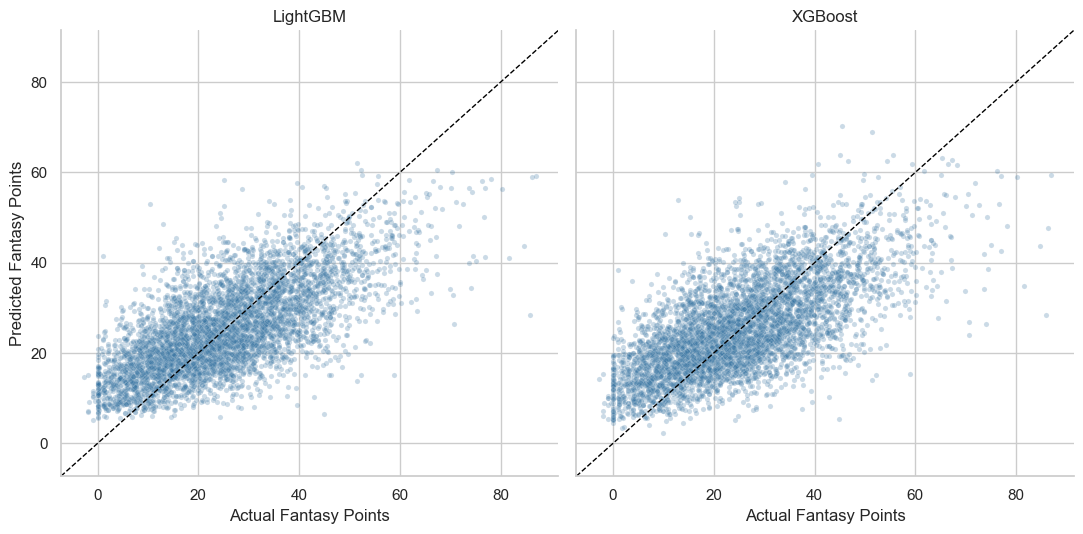

In [9]:
fantasy_predictions = predictions[predictions["target"] == "FANTASY_PTS"].copy()
scatter_sample = pd.concat(
    [
        group.sample(min(len(group), 5000), random_state=42)
        for _, group in fantasy_predictions.groupby("model")
    ],
    ignore_index=True,
)

grid = sns.FacetGrid(scatter_sample, col="model", height=5.5, aspect=1)
grid.map_dataframe(
    sns.scatterplot,
    x="actual",
    y="model_prediction",
    alpha=0.25,
    s=14,
    color="#2f6f9f",
)
for ax in grid.axes.flat:
    lower = min(ax.get_xlim()[0], ax.get_ylim()[0])
    upper = max(ax.get_xlim()[1], ax.get_ylim()[1])
    ax.plot([lower, upper], [lower, upper], linestyle="--", color="black", linewidth=1)
    ax.set_xlim(lower, upper)
    ax.set_ylim(lower, upper)
grid.set_axis_labels("Actual Fantasy Points", "Predicted Fantasy Points")
grid.set_titles("{col_name}")
plt.show()

## Fantasy Points: Error Distribution

Error is calculated as predicted fantasy points minus actual fantasy points. Values above zero are overpredictions; values below zero are underpredictions.

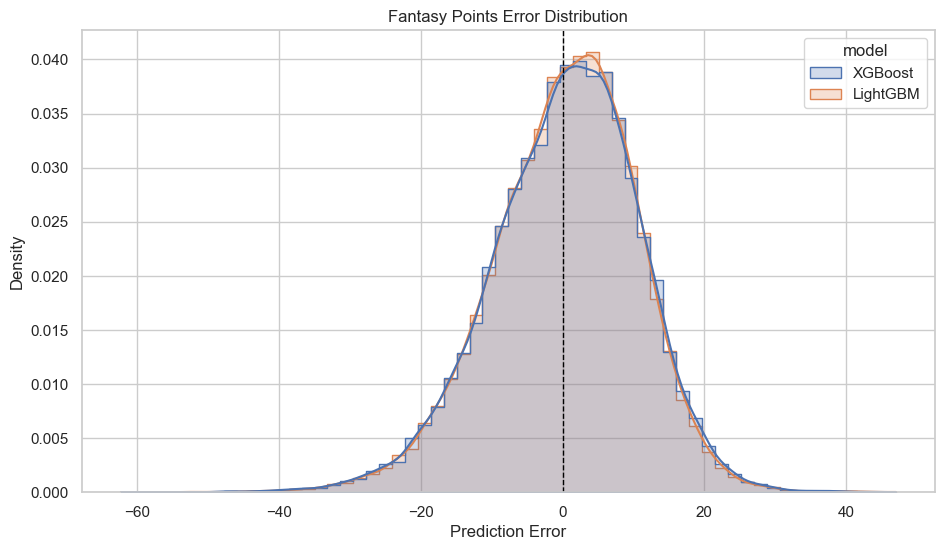

In [10]:
plt.figure(figsize=(11, 6))
sns.histplot(
    data=fantasy_predictions,
    x="error",
    hue="model",
    bins=60,
    kde=True,
    element="step",
    stat="density",
    common_norm=False,
)
plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.title("Fantasy Points Error Distribution")
plt.xlabel("Prediction Error")
plt.ylabel("Density")
plt.show()

## Models vs Baseline Performance: MAE

This compares models MAE against the train-average baseline for each target. Lower MAE is better.

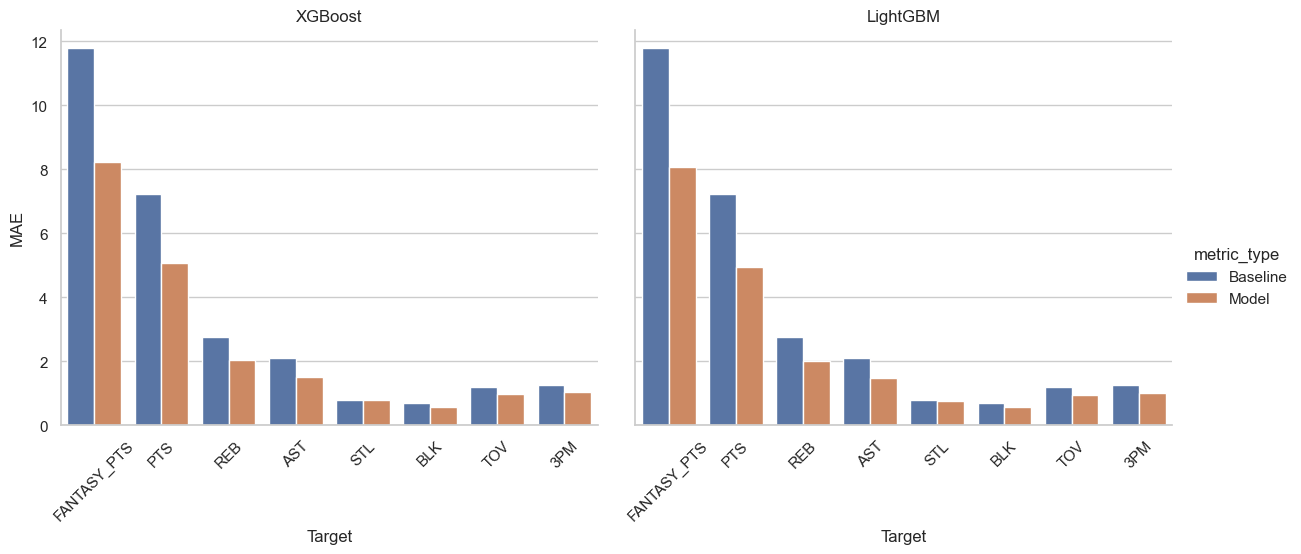

In [11]:
mae_long = metrics.melt(
    id_vars=["model", "target"],
    value_vars=["baseline_mae", "model_mae"],
    var_name="metric_type",
    value_name="mae",
)
mae_long["metric_type"] = mae_long["metric_type"].replace({
    "baseline_mae": "Baseline",
    "model_mae": "Model",
})

grid = sns.catplot(
    data=mae_long,
    x="target",
    y="mae",
    hue="metric_type",
    col="model",
    kind="bar",
    height=5,
    aspect=1.2,
)
grid.set_axis_labels("Target", "MAE")
grid.set_titles("{col_name}")
for ax in grid.axes.flat:
    ax.tick_params(axis="x", rotation=45)
plt.show()

## Models vs Baseline Performance: RMSE

This compares models MAE against the train-average baseline for each target. Lower RMSE is better.

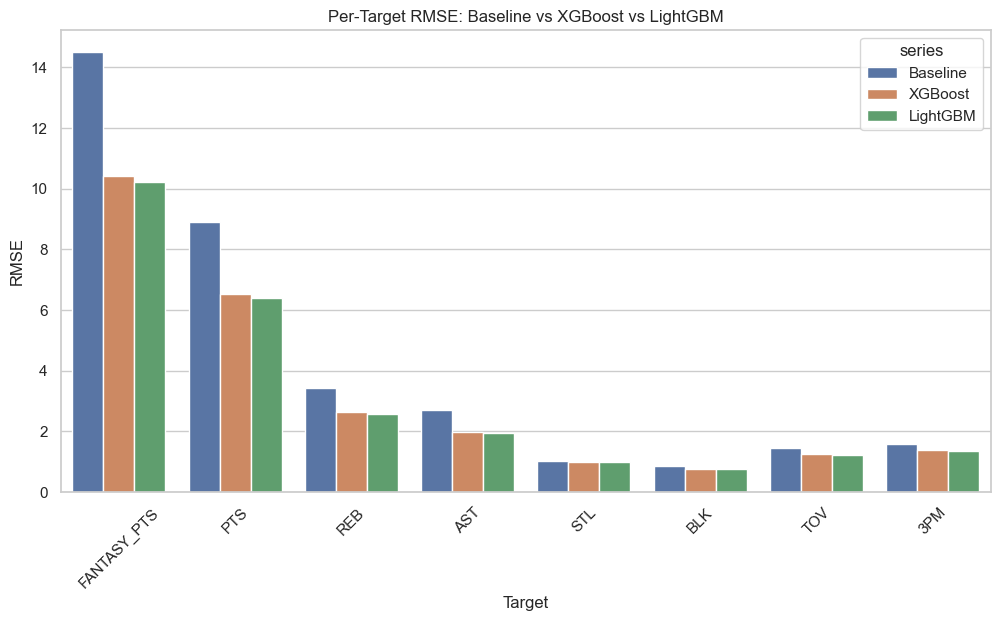

In [12]:
rmse_model = metrics[["model", "target", "model_rmse"]].rename(
    columns={"model": "series", "model_rmse": "rmse"}
)
rmse_baseline = (
    metrics[["target", "baseline_rmse"]]
    .drop_duplicates()
    .rename(columns={"baseline_rmse": "rmse"})
)
rmse_baseline["series"] = "Baseline"
rmse_long = pd.concat([rmse_baseline, rmse_model], ignore_index=True)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=rmse_long,
    x="target",
    y="rmse",
    hue="series",
    order=TARGET_ORDER,
    hue_order=["Baseline", "XGBoost", "LightGBM"],
)
plt.title("Per-Target RMSE: Baseline vs XGBoost vs LightGBM")
plt.xlabel("Target")
plt.ylabel("RMSE")
plt.xticks(rotation=45)
plt.show()

## Models vs Baseline Performance: R2

This compares models MAE against the train-average baseline for each target. Higher R2 is better.

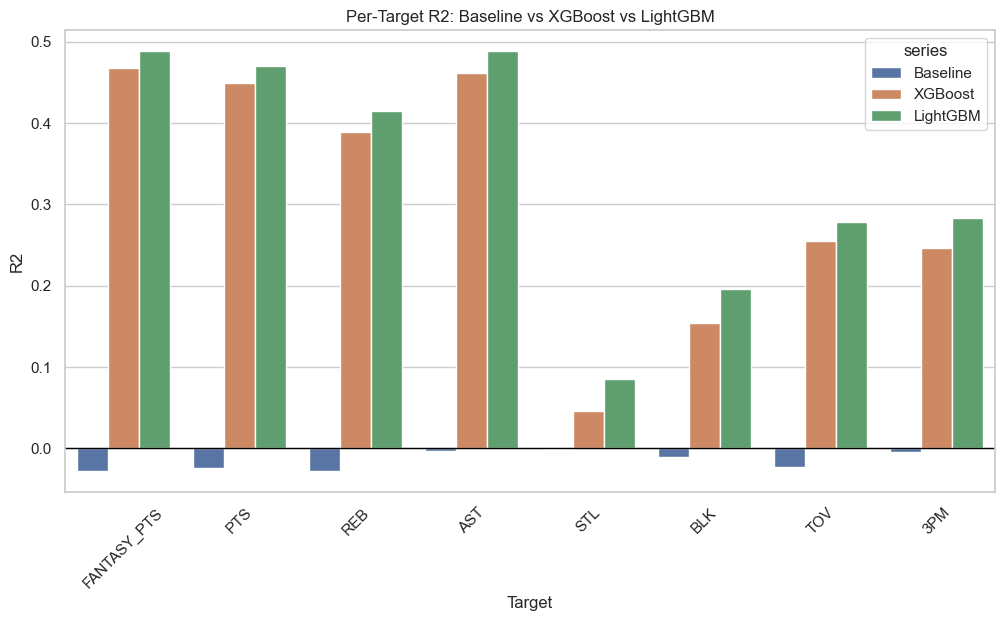

In [13]:
r2_model = metrics[["model", "target", "model_r2"]].rename(
    columns={"model": "series", "model_r2": "r2"}
)
r2_baseline = (
    metrics[["target", "baseline_r2"]]
    .drop_duplicates()
    .rename(columns={"baseline_r2": "r2"})
)
r2_baseline["series"] = "Baseline"
r2_long = pd.concat([r2_baseline, r2_model], ignore_index=True)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=r2_long,
    x="target",
    y="r2",
    hue="series",
    order=TARGET_ORDER,
    hue_order=["Baseline", "XGBoost", "LightGBM"],
)
plt.axhline(0, color="black", linewidth=1)
plt.title("Per-Target R2: Baseline vs XGBoost vs LightGBM")
plt.xlabel("Target")
plt.ylabel("R2")
plt.xticks(rotation=45)
plt.show()

## Key Insights

LightGBM slightly outperforms XGBoost across all eight targets based on the saved MAE, RMSE, and R2 results. The improvement is not huge, but it is consistent, which makes LightGBM a better model for this project.

Both models perform best on volume and usage-driven targets such as fantasy points, points, assists, and rebounds. These targets have stronger historical patterns, so rolling averages and lag features are especially useful.

Steals and blocks remain the hardest targets to predict. They are sparse defensive events, so even when the model beats the baseline, the R2 values stay relatively low.

The feature importance charts show that both models rely heavily on time-series features, especially rolling fantasy-points averages when predicting fantasy points.